In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy import stats
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'text.usetex':        False,
    'font.family':        'serif',
    'font.serif':         ['DejaVu Serif'],
    'axes.labelsize':     18,
    'font.size':          11,
    'legend.fontsize':    9,
    'xtick.labelsize':    18,
    'ytick.labelsize':    16,
    'axes.titlesize':     16,
    'figure.dpi':         600,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'grid.linewidth':     0.5,
})

COLORS = {
    'ZIP':    '#2196F3',
    'PRSH':   '#4CAF50',
    'ZIC':    '#9C27B0',
    'CUSTOM': '#FF6B35',
    'SNPR':   '#795548',
    'SHVR':   '#607D8B',
    'GVWY':   '#9E9E9E',
}

OUT          = '.'
DATA_PATH    = 'data/final_results.csv'
TRADER_ORDER = ['CUSTOM', 'PRSH', 'ZIC', 'SHVR', 'SNPR', 'ZIP', 'GVWY']
TOP3         = ['ZIP', 'CUSTOM', 'PRSH']
CONDITIONS   = ['stable', 'shock_up', 'shock_down', 'multi_regime']
COND_LABELS  = ['Stable', 'Shock Up', 'Shock Down', 'Multi-Regime']

df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df)} rows | traders: {df["ttype"].unique().tolist()}')

Loaded 21000 rows | traders: ['GVWY', 'ZIC', 'SHVR', 'SNPR', 'ZIP', 'PRSH', 'CUSTOM']


In [31]:
# Summary table — mean profit and trades per trader type across all conditions
summary = (df.groupby('ttype')
             .agg(mean_profit=('final_profit', 'mean'),
                  mean_trades=('n_trades', 'mean'))
             .round(2)
             .reset_index()
             .sort_values('mean_profit', ascending=False))
summary.columns = ['Trader Type', 'Mean Profit per Trader', 'Mean Trades per Trader']
#summary.to_csv(f'figures/summary_statistics.csv', index=False)
summary

,Trader Type,Mean Profit per Trader,Mean Trades per Trader
6,ZIP,7060.80,3749.81
0,CUSTOM,5164.91,4675.15
2,PRSH,1950.64,1211.84
5,ZIC,1273.53,588.59
4,SNPR,-1169.64,1269.49
3,SHVR,-5149.69,5854.79
1,GVWY,-9020.39,6518.26


In [54]:
# Risk-adjusted merge cell removed (file not required for report figures)


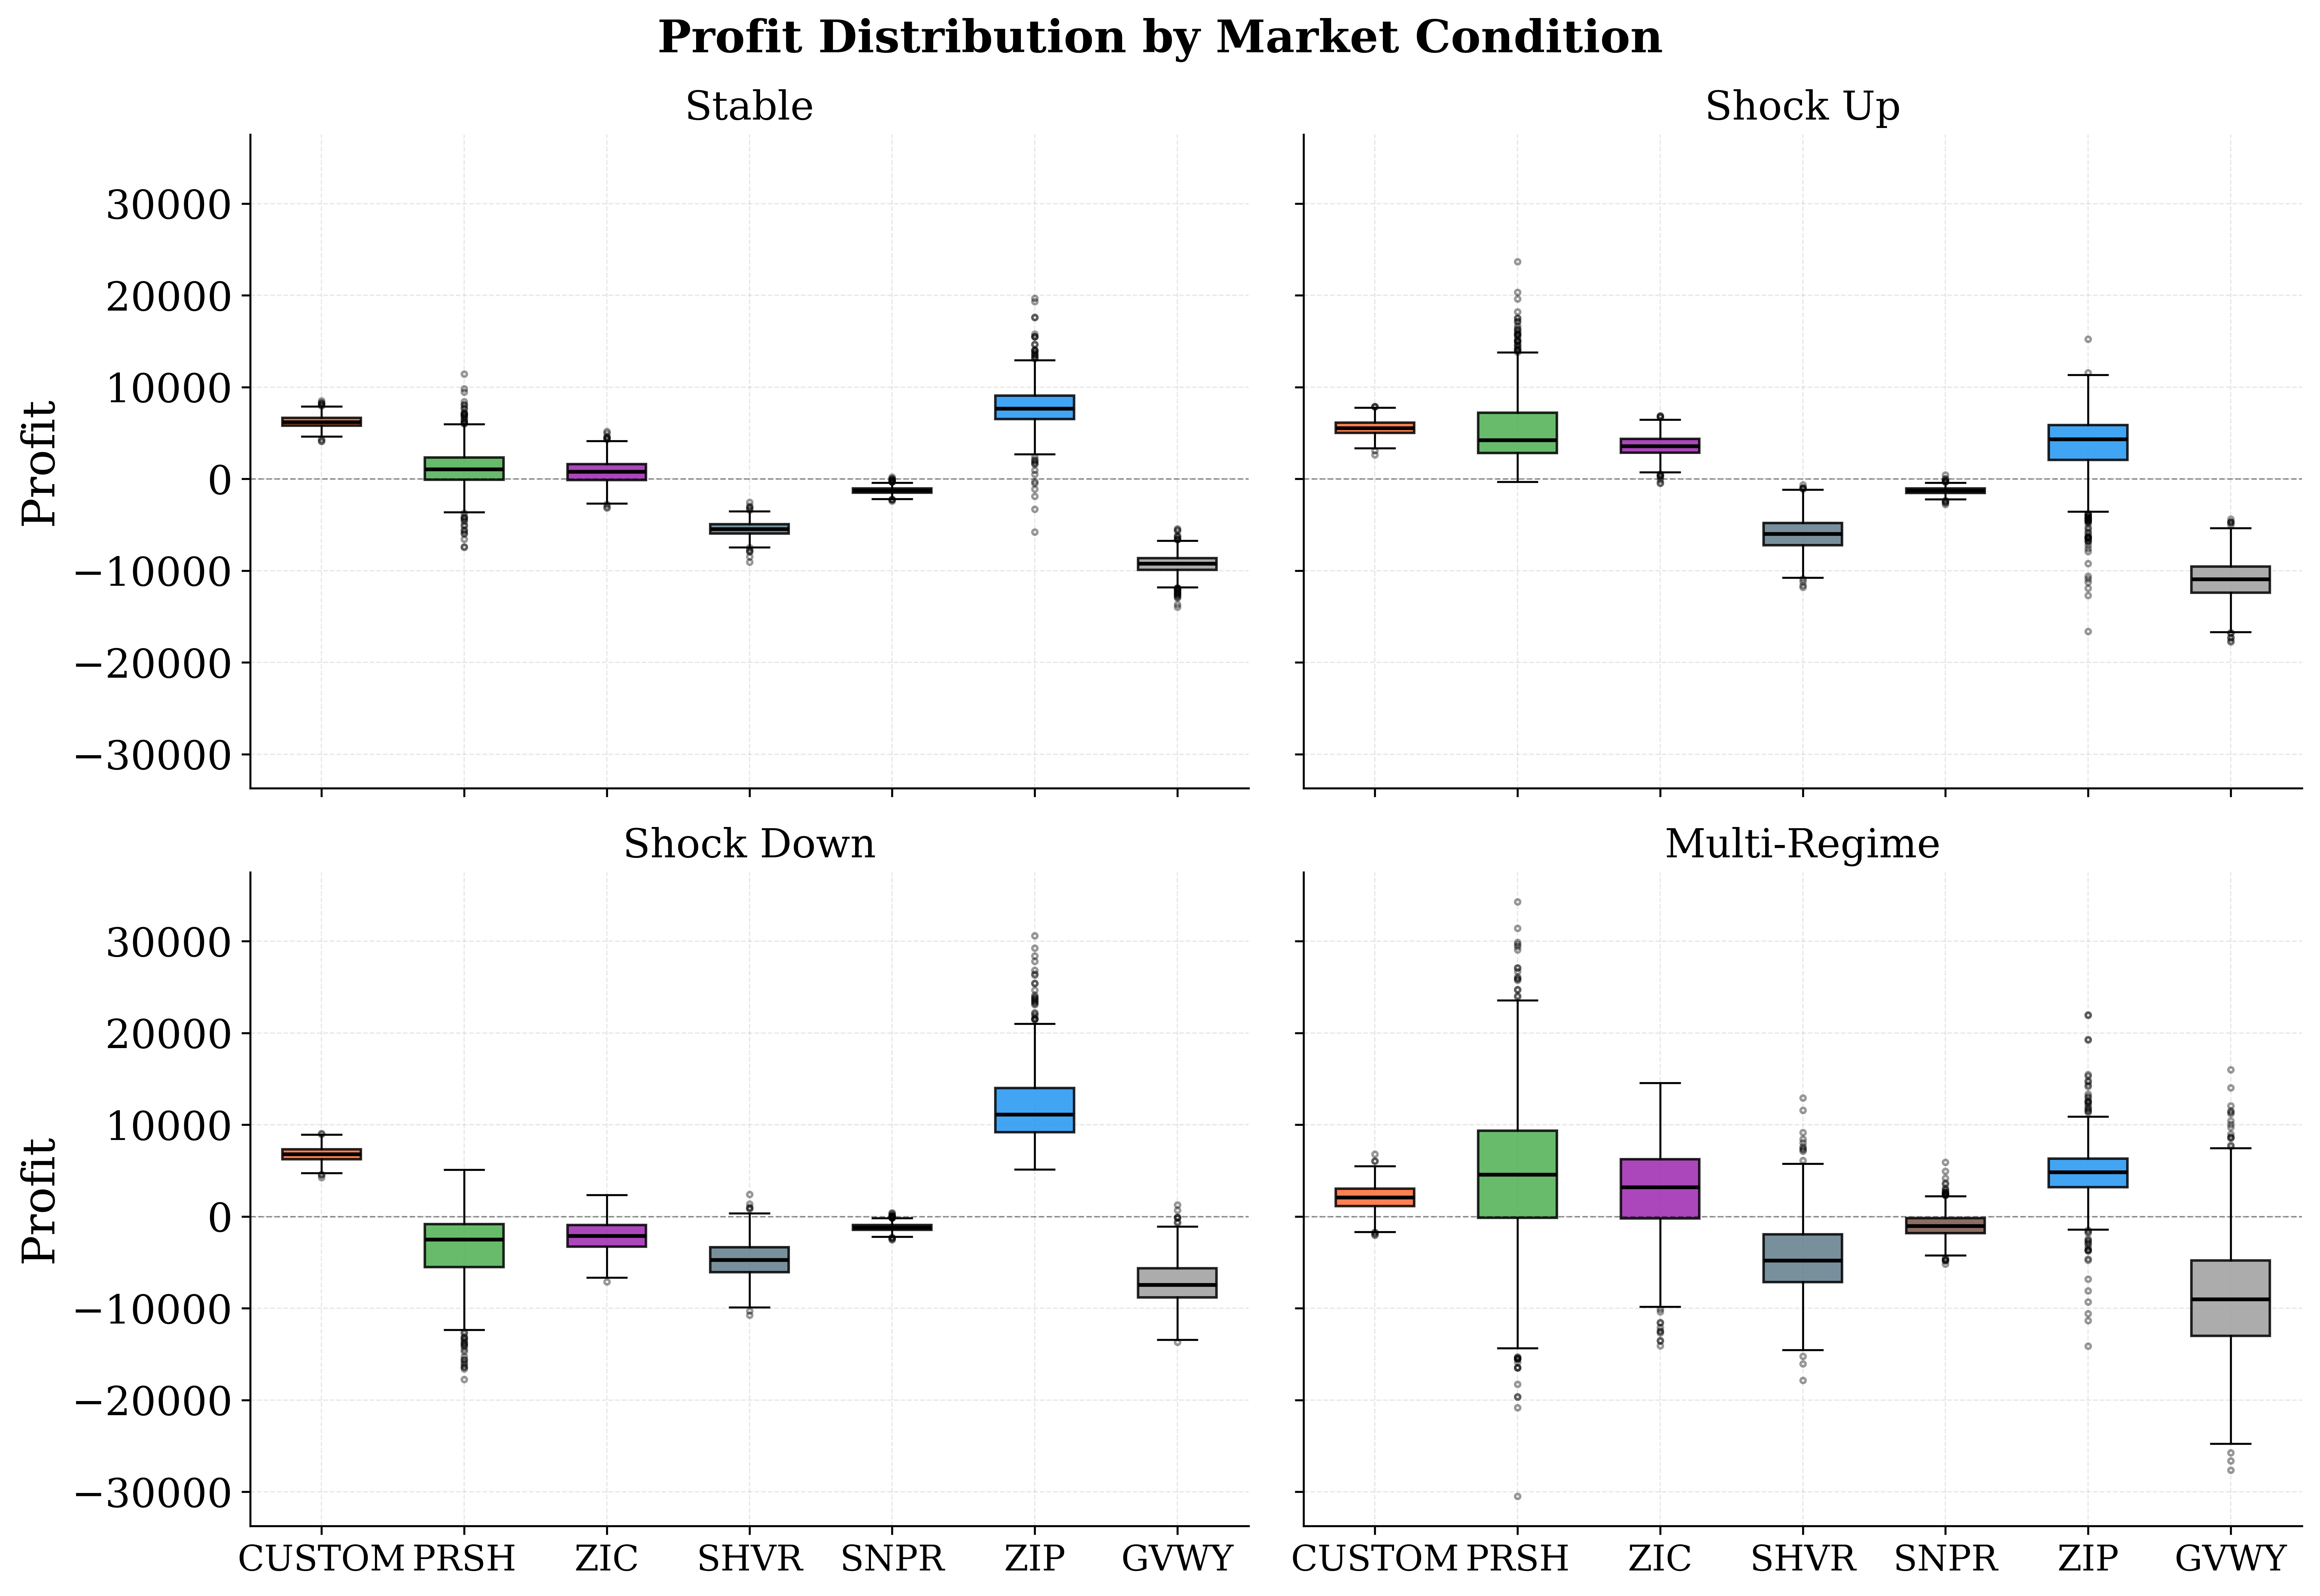

In [32]:
# Profit distribution box plot — one subplot per condition
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
axes = axes.flatten()

# 2. Wrapped the zip in enumerate to track the index (i)
for i, (ax, cond, clabel) in enumerate(zip(axes, CONDITIONS, COND_LABELS)):
    cdf  = df[df['condition'] == cond]
    data = [cdf[cdf['ttype'] == t]['final_profit'].values for t in TRADER_ORDER]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.55,
                      medianprops=dict(color='black', linewidth=1.5),
                      whiskerprops=dict(linewidth=0.8),
                      capprops=dict(linewidth=0.8),
                      flierprops=dict(marker='o', markersize=2, alpha=0.4, linewidth=0))
    
    for patch, t in zip(bp['boxes'], TRADER_ORDER):
        patch.set_facecolor(COLORS[t])
        patch.set_alpha(0.85)
        
    ax.set_xticks(range(1, len(TRADER_ORDER) + 1))
    
    # Conditionally set X-axis labels only for the bottom row (indices 2 and 3)
    if i >= 2:
        ax.set_xticklabels(TRADER_ORDER, fontsize=14)
        
    # Conditionally set Y-axis labels only for the left column (indices 0 and 2)
    if i % 2 == 0:
        ax.set_ylabel('Profit')
        
    ax.set_title(clabel)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)

fig.suptitle('Profit Distribution by Market Condition', fontsize=18, fontweight='bold')
plt.tight_layout()
#plt.savefig(f'figures/Profits.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# Volatility-specific performance — shock_up and multi_regime only
vol_df = df[df['condition'].isin(['shock_up', 'multi_regime'])]
vol_summary = (vol_df.groupby('ttype')
                     .agg(mean_profit=('final_profit', 'mean'),
                          mean_trades=('n_trades', 'mean'))
                     .round(2)
                     .reset_index()
                     .sort_values('mean_profit', ascending=False))
vol_summary.columns = ['Trader Type', 'Mean Profit (Volatile)', 'Mean Trades (Volatile)']
#vol_summary.to_csv(f'figures/volatility_summary.csv', index=False)
vol_summary

,Trader Type,Mean Profit (Volatile),Mean Trades (Volatile)
2,PRSH,5061.37,1195.89
6,ZIP,4186.26,3831.10
0,CUSTOM,3820.66,4593.43
5,ZIC,3188.85,586.86
4,SNPR,-1109.06,1236.52
3,SHVR,-5251.42,5682.68
1,GVWY,-9784.73,6394.07


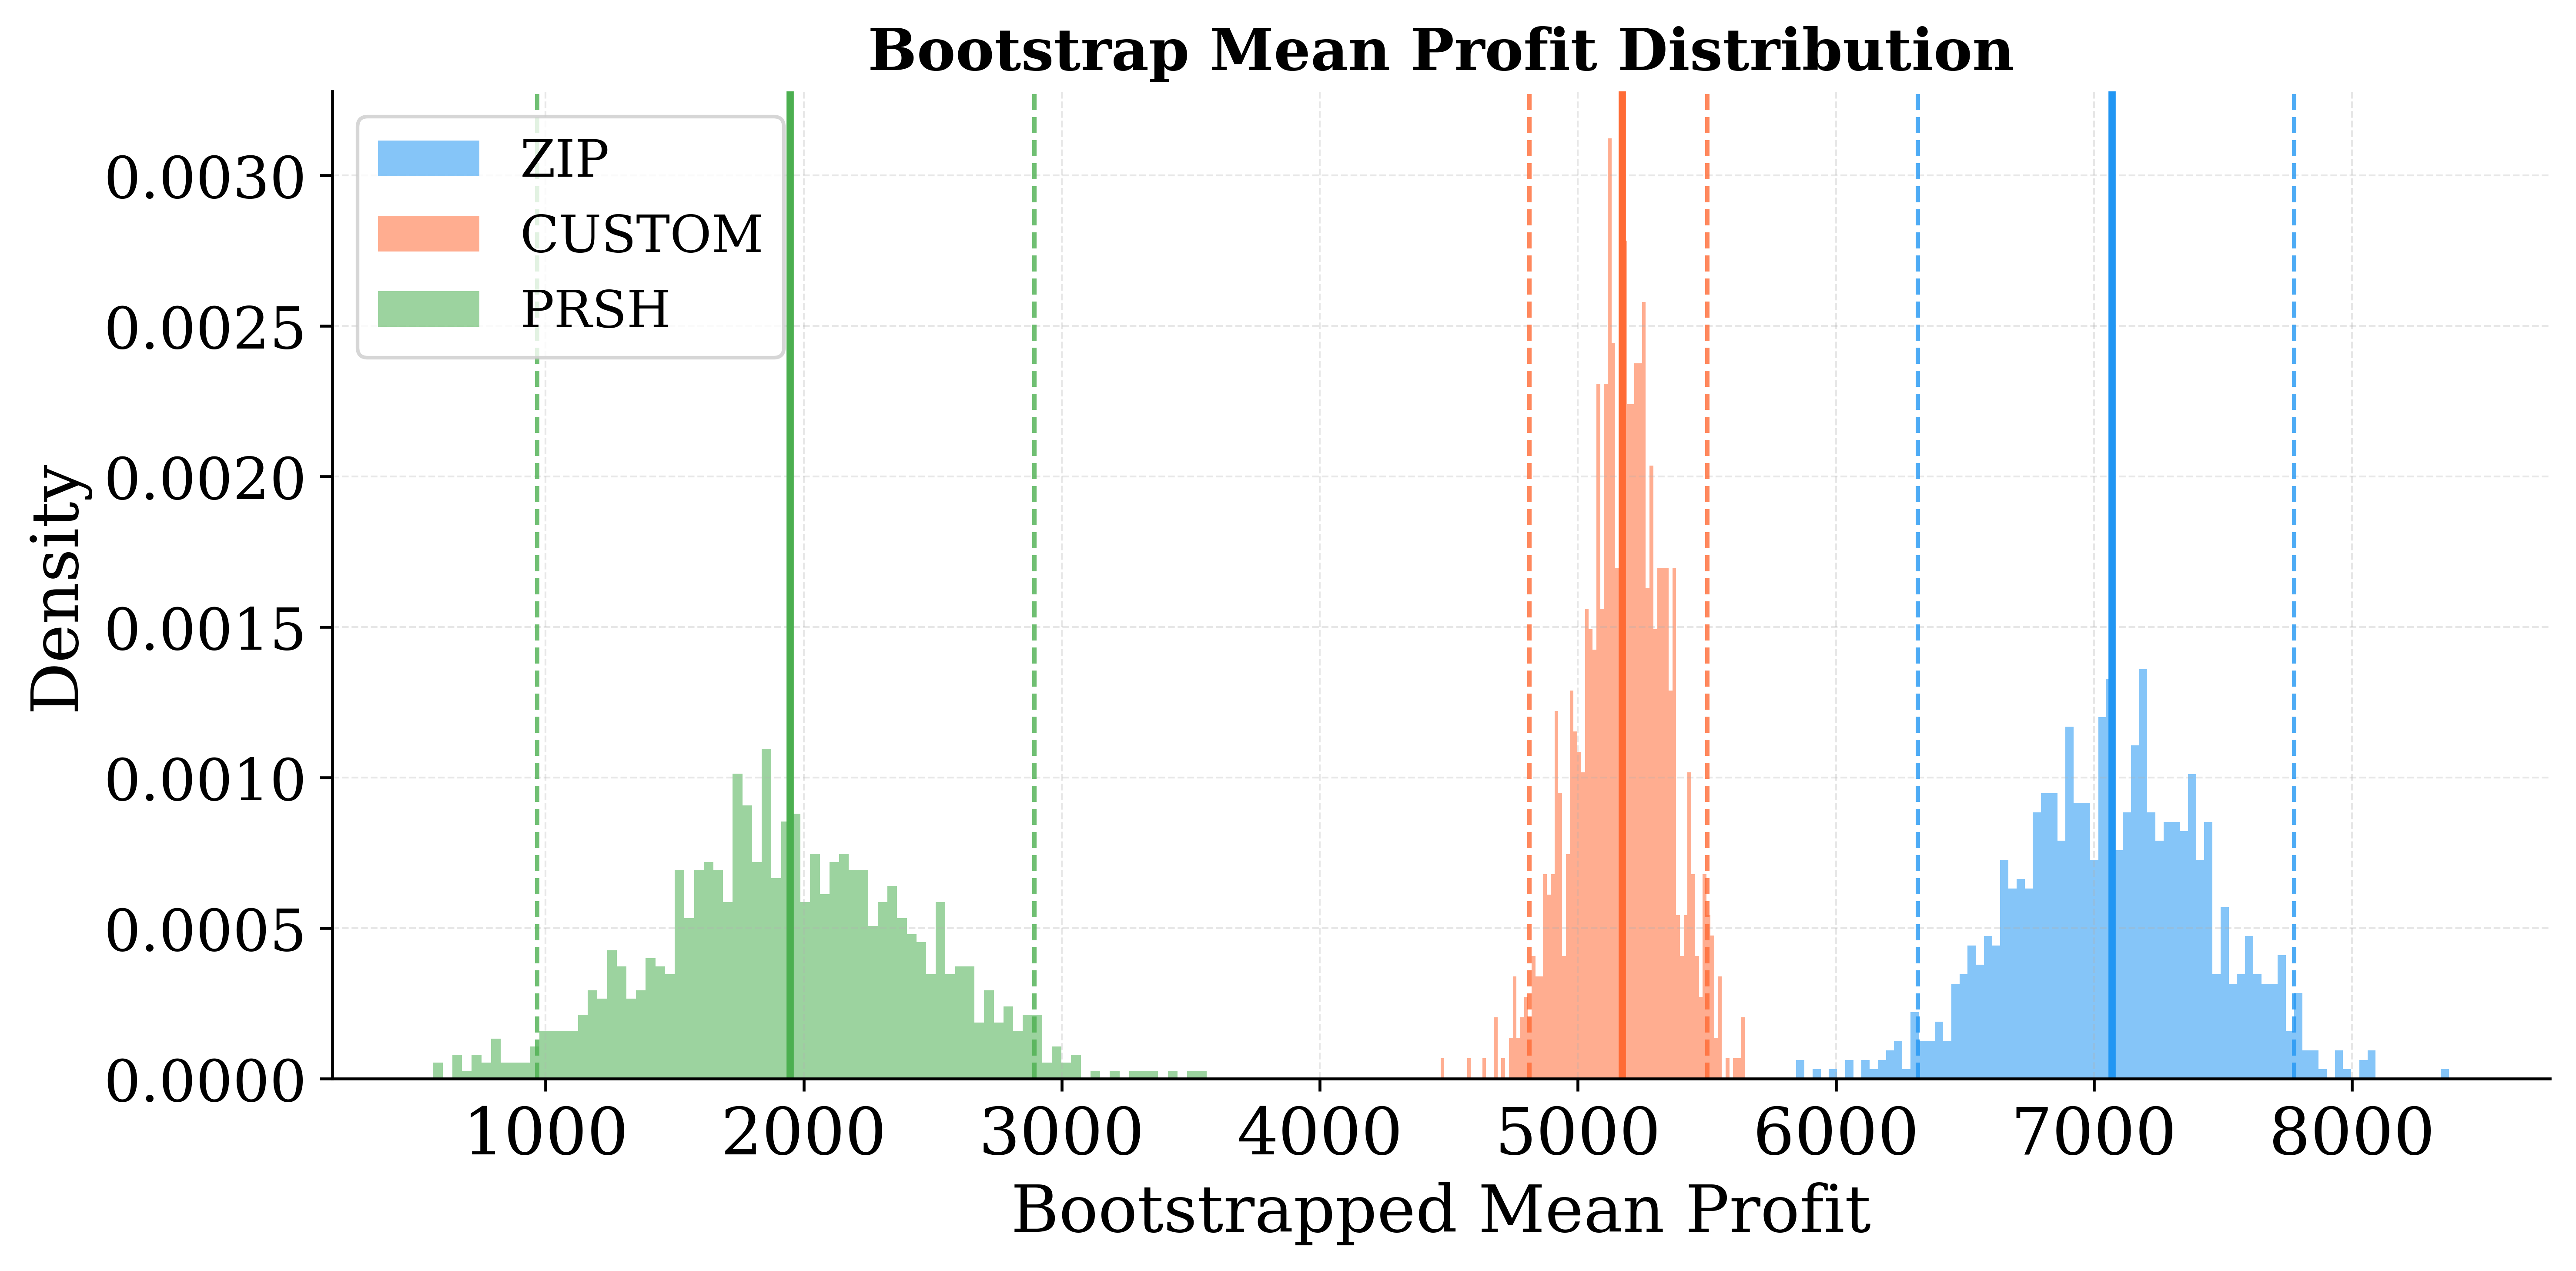

,Trader,CI_lower,CI_upper,Boot_mean
0,ZIP,6316.78,7776.11,7068.67
1,CUSTOM,4813.06,5501.02,5171.64
2,PRSH,967.87,2894.78,1946.18


In [43]:
# Bootstrap mean estimation — n=150, K=10,000
N_BOOT, N_SAMP = 1000, 150
rng = np.random.default_rng(42)

boot_results = {}
ci_results   = {}
for t in TOP3:
    profits        = df[df['ttype'] == t]['final_profit'].values
    samples        = rng.choice(profits, size=(N_BOOT, N_SAMP), replace=True)
    means          = samples.mean(axis=1)
    boot_results[t] = means
    ci_results[t]   = (np.percentile(means, 2.5), np.percentile(means, 97.5))

pd.DataFrame(boot_results).to_csv(f'figures/bootstrap_means.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5))
for t in TOP3:
    vals  = boot_results[t]
    lo, hi = ci_results[t]
    ax.hist(vals, bins=80, alpha=0.55, color=COLORS[t], density=True, label=t)
    ax.axvline(lo,          color=COLORS[t], linewidth=1.2, linestyle='--', alpha=0.8)
    ax.axvline(hi,          color=COLORS[t], linewidth=1.2, linestyle='--', alpha=0.8)
    ax.axvline(vals.mean(), color=COLORS[t], linewidth=2.0)
ax.set_xlabel('Bootstrapped Mean Profit')
ax.set_ylabel('Density')
ax.set_title('Bootstrap Mean Profit Distribution', fontweight='bold')
ax.legend(fontsize=14)
plt.tight_layout()
#plt.savefig(f'figures/Bootstrap_means.png', dpi=300, bbox_inches='tight')
plt.show()

ci_df = pd.DataFrame({'Trader': TOP3,
                       'CI_lower':  [ci_results[t][0] for t in TOP3],
                       'CI_upper':  [ci_results[t][1] for t in TOP3],
                       'Boot_mean': [boot_results[t].mean() for t in TOP3]}).round(2)
#ci_df.to_csv(f'figures/bootstrap_CI.csv', index=False)
ci_df

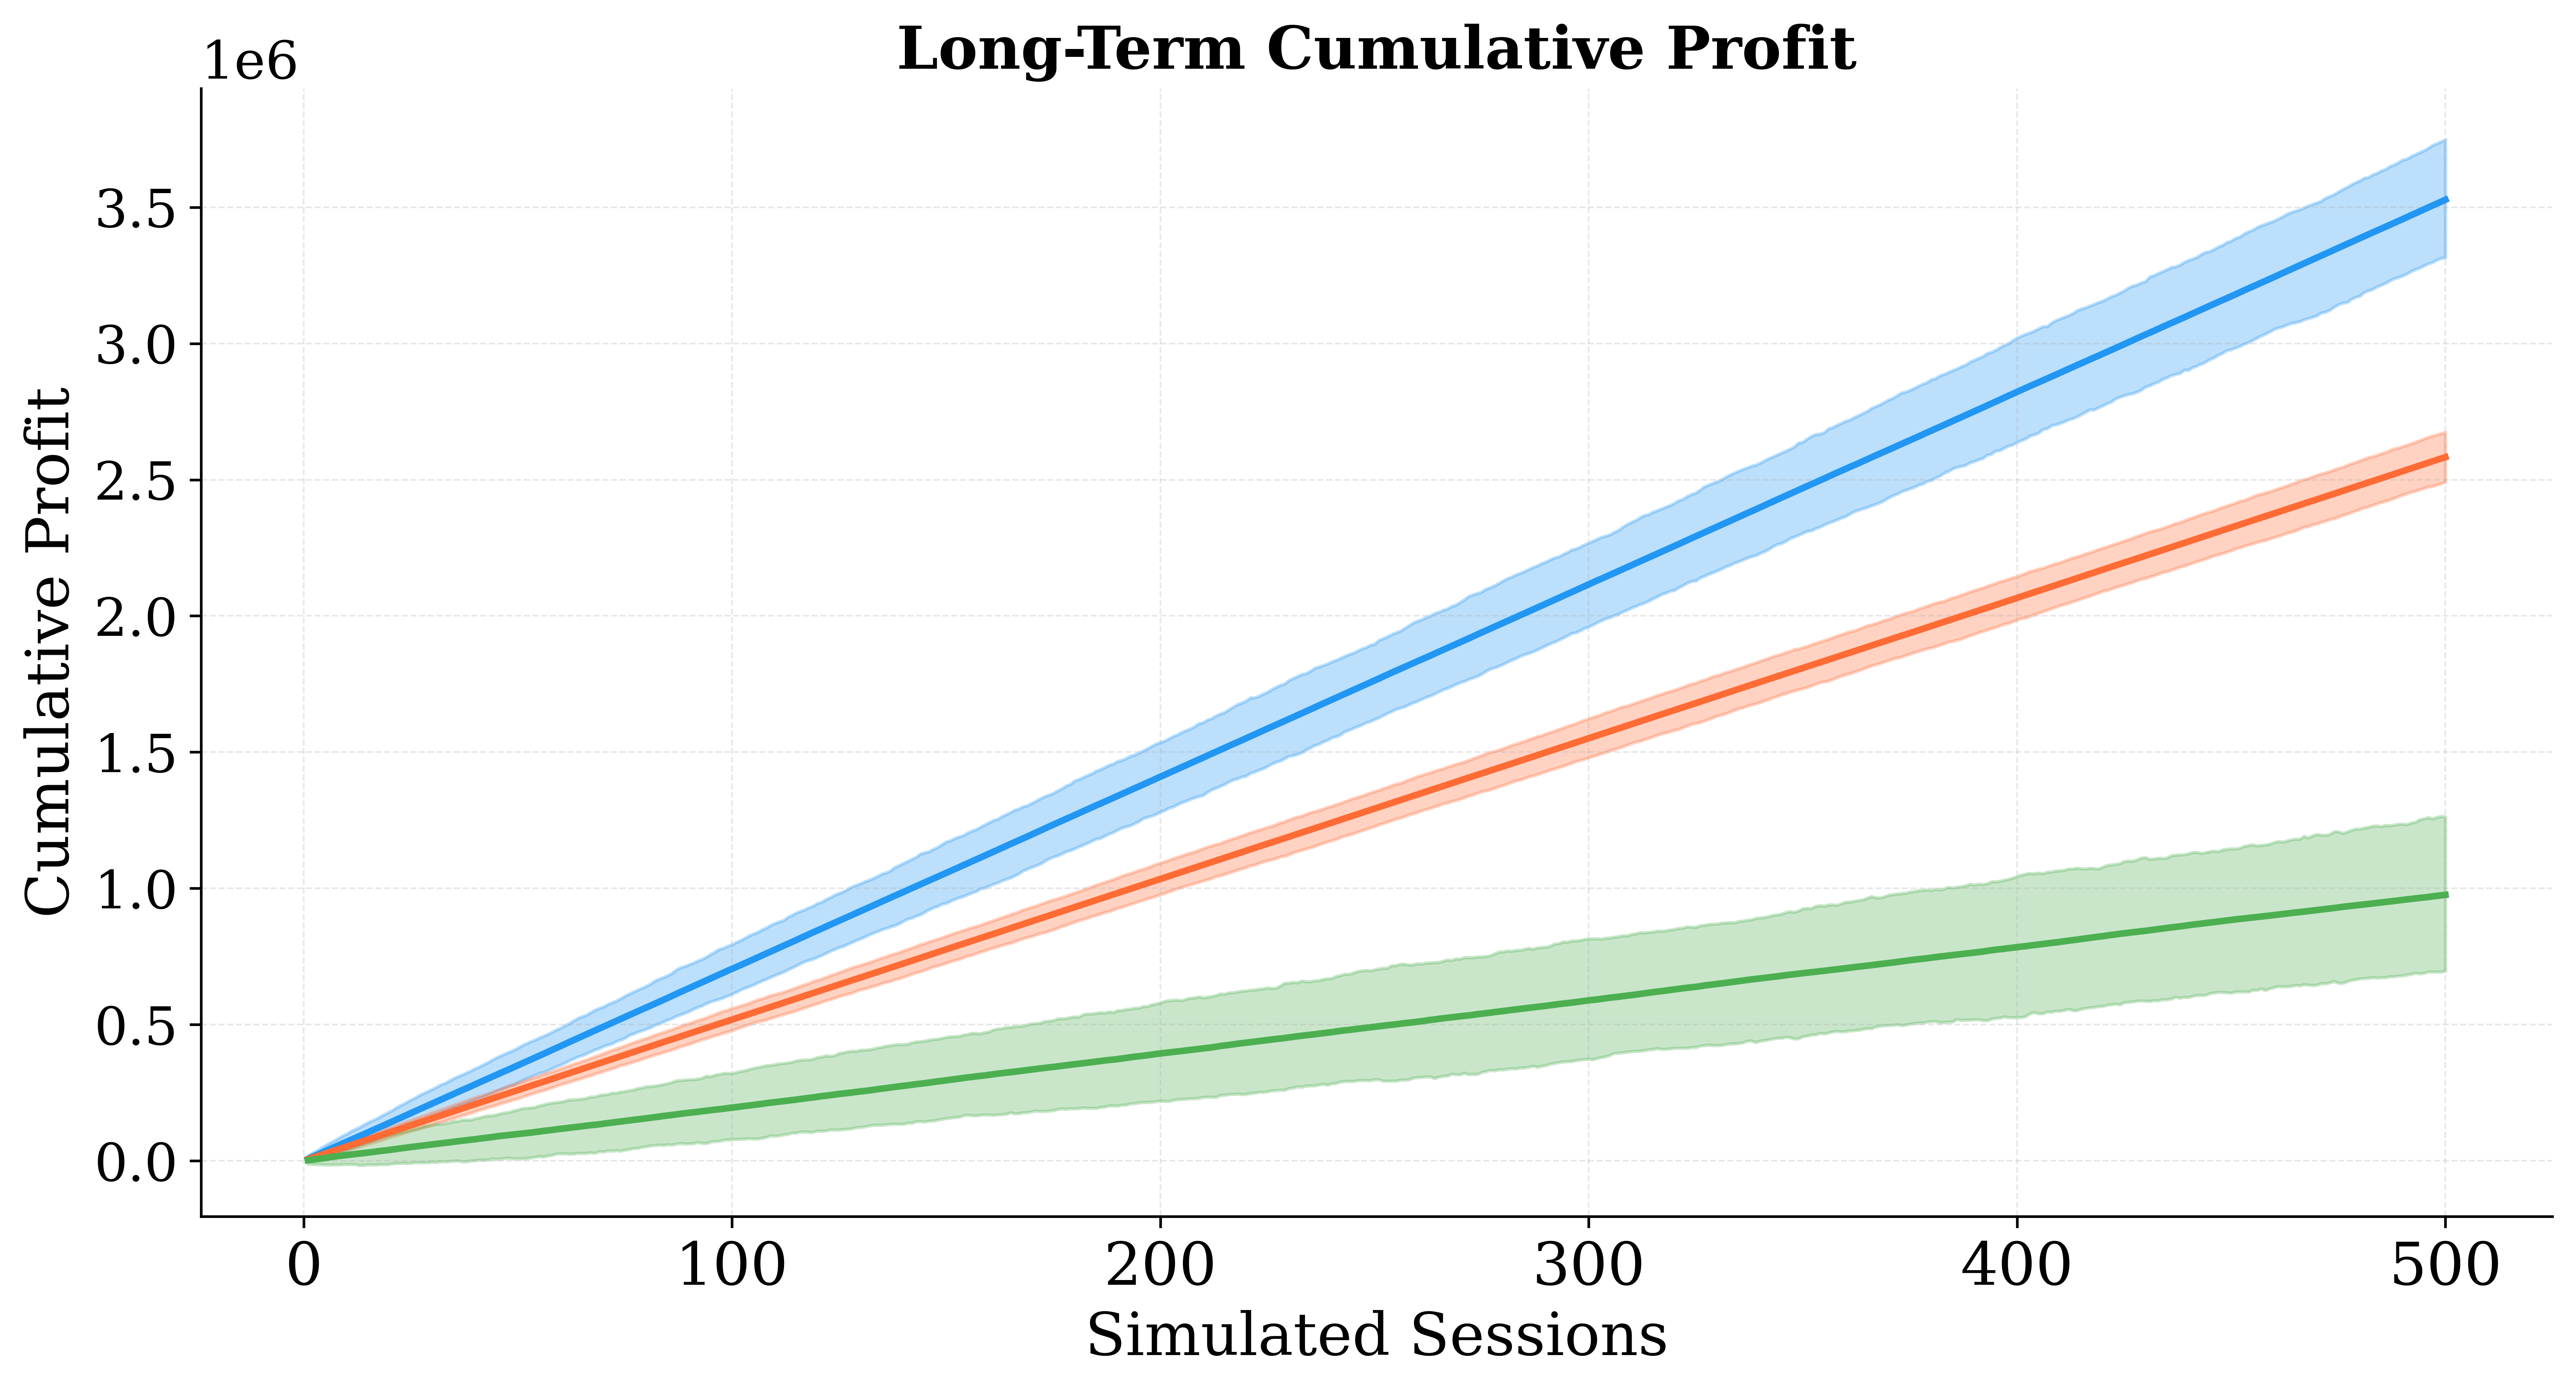

In [55]:
# Long-term cumulative profit simulation — B=1000, N=500 sessions
B, N_SIM = 1000, 500

fig, ax = plt.subplots(figsize=(11, 6))
cum_records = {'session': np.arange(1, N_SIM + 1)}

for t in TOP3:
    profits = df[df['ttype'] == t]['final_profit'].values
    draws   = rng.choice(profits, size=(B, N_SIM), replace=True)
    cum     = draws.cumsum(axis=1)
    mean_c  = cum.mean(axis=0)
    lo_c    = np.percentile(cum, 2.5,  axis=0)
    hi_c    = np.percentile(cum, 97.5, axis=0)
    x = np.arange(1, N_SIM + 1)
    ax.plot(x, mean_c, color=COLORS[t], linewidth=2.0)
    ax.fill_between(x, lo_c, hi_c, color=COLORS[t], alpha=0.3)
    cum_records[f'{t}_mean'] = mean_c
    cum_records[f'{t}_lo']   = lo_c
    cum_records[f'{t}_hi']   = hi_c

ax.set_xlabel('Simulated Sessions')
ax.set_ylabel('Cumulative Profit')
ax.set_title('Long-Term Cumulative Profit', fontweight='bold', fontsize=18)
plt.tight_layout()
#plt.savefig(f'figures/Bootstrap_cumulative.png', dpi=300, bbox_inches='tight')
plt.show()

#pd.DataFrame(cum_records).round(2).to_csv(f'figures/bootstrap_cumulative.csv', index=False)

In [17]:
# Bootstrap CI overlap test — do CUSTOM CIs overlap with ZIP / PRSH?
overlap_results = []
custom_lo, custom_hi = ci_results['CUSTOM']
for t in ['ZIP', 'PRSH']:
    t_lo, t_hi = ci_results[t]
    overlaps = not (custom_hi < t_lo or t_hi < custom_lo)
    overlap_width = max(0, min(custom_hi, t_hi) - max(custom_lo, t_lo))
    overlap_results.append({'CUSTOM vs': t, 'CUSTOM CI': f'[{custom_lo:.0f}, {custom_hi:.0f}]',
                             f'{t} CI': f'[{t_lo:.0f}, {t_hi:.0f}]',
                             'Overlaps': overlaps, 'Overlap width': round(overlap_width, 1)})

overlap_df = pd.DataFrame(overlap_results)
#overlap_df.to_csv(f'figures/CI_overlap.csv', index=False)
overlap_df

,CUSTOM vs,CUSTOM CI,ZIP CI,Overlaps,Overlap width,PRSH CI
0,ZIP,"[4822, 5488]","[6319, 7828]",False,0,NaN
1,PRSH,"[4822, 5488]",NaN,False,0,"[981, 2970]"
